# CHANGING NARRATIVES OF MIGRATION (1979-2015)
**Course:** Text Mining and Analysis (ADIN019NABB)  
**Team:** Jonathán Adorjáni, Gábor Mátay-Csepeli, Lívia Sólyom

In [1]:
#pip install --upgrade pip setuptools wheel
#!pip install spacy==3.7.5
#!python -m spacy download en_core_web_sm

In [1]:
# importing
import pandas as pd
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import re
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
import spacy
from collections import Counter
import numpy as np

# Download the necessary resources (as we learned in Week 1)
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')
nltk.download('punkt-tab')
nltk.download('omw-1.4')

nlp = spacy.load('en_core_web_sm')
print('spaCy pipeline:', nlp.pipe_names)

[nltk_data] Downloading package stopwords to /Users/mac/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /Users/mac/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to /Users/mac/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Error loading punkt-tab: Package 'punkt-tab' not found in
[nltk_data]     index
[nltk_data] Downloading package omw-1.4 to /Users/mac/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


spaCy pipeline: ['tok2vec', 'tagger', 'parser', 'attribute_ruler', 'lemmatizer', 'ner']


In [4]:
# Loading the dataset
df = pd.read_csv('/Volumes/samsung_t7/hansard-speeches-v310.csv')
# df = pd.read_csv('hansard-speeches-v310.csv')

<positron-console-cell-4>:2: DtypeWarning: Columns (8,10,11,12,15,16,18) have mixed types. Specify dtype option on import or set low_memory=False.


In [5]:
#!pip install --upgrade --force-reinstall nltk

In [4]:
df.head()

,id,speech,display_as,party,constituency,mnis_id,date,time,colnum,speech_class,major_heading,minor_heading,oral_heading,year,hansard_membership_id,speakerid,person_id,speakername,url
0,uk.org.publicwhip/debate/1979-05-09a.1.1,"The House being met; and, it being the first d...",Unknown,NaN,NaN,NaN,1979-05-09,NaN,1,Procedural,Preamble,NaN,NaN,1979,NaN,NaN,NaN,Unknown,NaN
1,uk.org.publicwhip/debate/1979-05-09a.1.2,Several of the Members repaired to their Seats.,Unknown,NaN,NaN,NaN,1979-05-09,NaN,1,Procedural,Preamble,NaN,NaN,1979,NaN,NaN,NaN,Unknown,NaN
2,uk.org.publicwhip/debate/1979-05-09a.1.3,"JOHN PARKER, ESQUIRE, took the Chair, pursuant...",Unknown,NaN,NaN,NaN,1979-05-09,NaN,1,Procedural,Preamble,NaN,NaN,1979,NaN,NaN,NaN,Unknown,NaN
3,uk.org.publicwhip/debate/1979-05-09a.1.4,Message to attend the Lords Commissioners;,Unknown,NaN,NaN,NaN,1979-05-09,NaN,1,Procedural,Preamble,NaN,NaN,1979,NaN,NaN,NaN,Unknown,NaN
4,uk.org.publicwhip/debate/1979-05-09a.1.5,The House went; and a Commission having been r...,Unknown,NaN,NaN,NaN,1979-05-09,NaN,1,Procedural,Preamble,NaN,NaN,1979,NaN,NaN,NaN,Unknown,NaN


In [5]:
df.tail()

,id,speech,display_as,party,constituency,mnis_id,date,time,colnum,speech_class,major_heading,minor_heading,oral_heading,year,hansard_membership_id,speakerid,person_id,speakername,url
2694370,uk.org.publicwhip/debate/2021-04-29a.519.2,I totally agree with everything that the right...,Lindsay Hoyle,Speaker,Chorley,467.0,2021-04-29,10:38:00,519,Speech,Point of Order,NaN,NaN,2021,NaN,NaN,uk.org.publicwhip/person/10295,Lindsay Hoyle,NaN
2694371,uk.org.publicwhip/debate/2021-04-29a.519.4,Message to attend the Lords Commissioners deli...,Unknown,NaN,NaN,NaN,2021-04-29,14:27:00,519,Procedural,Message to Attend the Lords Commissioners,NaN,NaN,2021,NaN,NaN,NaN,Unknown,NaN
2694372,uk.org.publicwhip/debate/2021-04-29a.519.6,I have to acquaint the House that the House ha...,Lindsay Hoyle,Speaker,Chorley,467.0,2021-04-29,14:27:00,519,Speech,Royal Assent,NaN,NaN,2021,NaN,NaN,uk.org.publicwhip/person/10295,Lindsay Hoyle,NaN
2694373,uk.org.publicwhip/debate/2021-04-29a.521.1,I have further to acquaint the House that the ...,Lindsay Hoyle,Speaker,Chorley,467.0,2021-04-29,14:27:00,521,Speech,Her Majesty’s Most Gracious Speech,NaN,NaN,2021,NaN,NaN,uk.org.publicwhip/person/10295,Lindsay Hoyle,NaN
2694374,uk.org.publicwhip/debate/2021-04-29a.524.1,The Commission was also for proroguing this pr...,Lindsay Hoyle,Speaker,Chorley,467.0,2021-04-29,14:27:00,524,Speech,Prorogation,NaN,NaN,2021,NaN,NaN,uk.org.publicwhip/person/10295,Lindsay Hoyle,NaN


In [9]:
len(df.drop_duplicates(subset=["id","speakername"]))

2694375

In [10]:
# Filter for migration-related keywords
keywords = ['migration', 'migrant', 'immigrant', 'immigration', 'refugee', 'asylum', 'deportation', 'border control', 'asylum seeker', 'visa', 'citizenship']
pattern = '|'.join(keywords)
df_migration = df[df['speech'].str.contains(pattern, case=False, na=False)].copy()

# Convert date to datetime
df_migration['date'] = pd.to_datetime(df_migration['date'])
df_migration['year'] = df_migration['date'].dt.year

print(f"Original speeches: {len(df)}")
print(f"Filtered migration-related speeches: {len(df_migration)}")

Original speeches: 2694375
Filtered migration-related speeches: 58729


### Some descriptive statistics

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

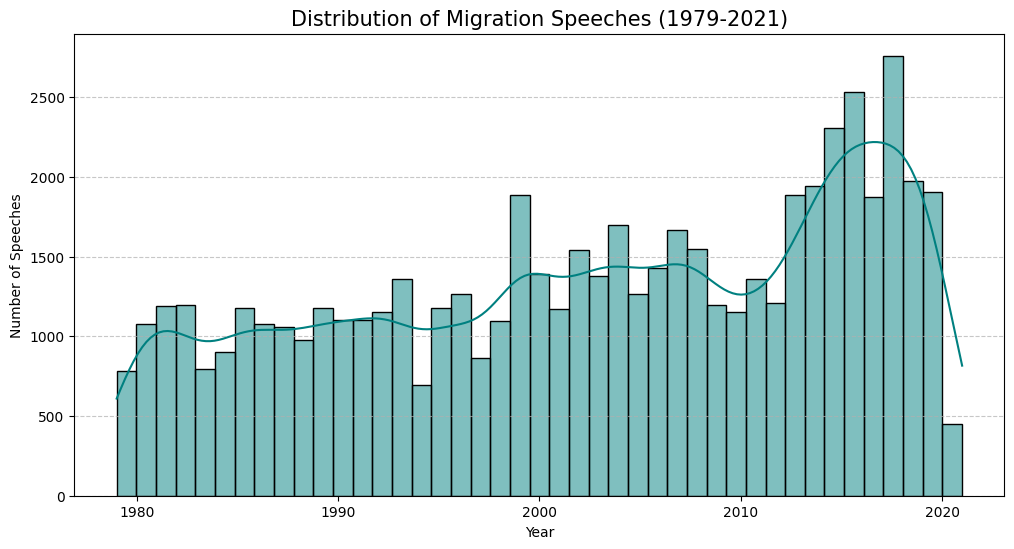

Years with the highest volume of migration debates:
year
2018    2759
2016    2532
2015    2305
2019    1971
2014    1941
Name: count, dtype: int64


In [13]:
# Speeches per Year
plt.figure(figsize=(12, 6))
sns.histplot(df_migration['year'], bins=len(df_migration['year'].unique()), kde=True, color='teal')
plt.title('Distribution of Migration Speeches (1979-2021)', fontsize=15)
plt.xlabel('Year')
plt.ylabel('Number of Speeches')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

top_years = df_migration['year'].value_counts().head(5)
print("Years with the highest volume of migration debates:")
print(top_years)

<positron-console-cell-14>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



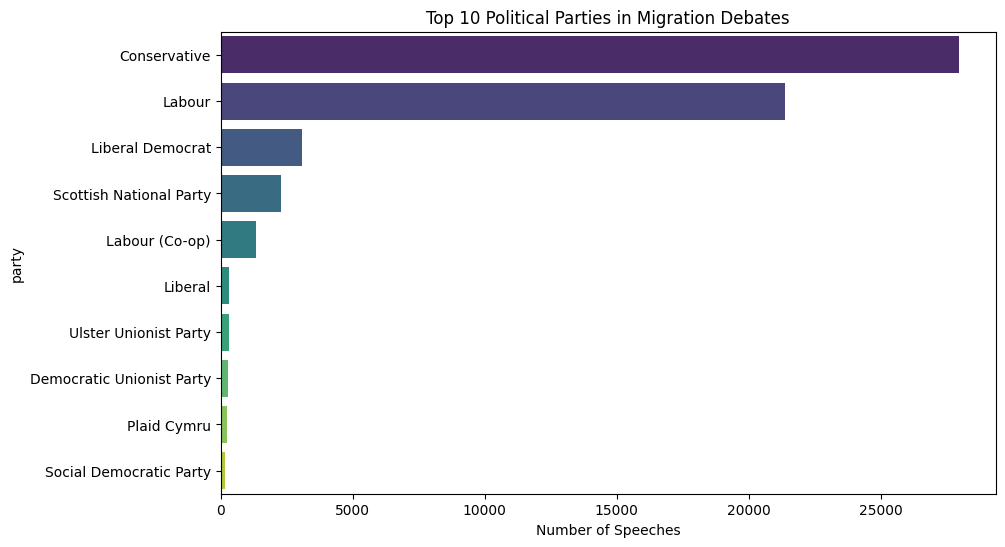

In [14]:
# Distribution by Political Party

party_counts = df_migration['party'].value_counts().head(10) # Top 10 parties
plt.figure(figsize=(10, 6))
sns.barplot(x=party_counts.values, y=party_counts.index, palette='viridis')
plt.title('Top 10 Political Parties in Migration Debates')
plt.xlabel('Number of Speeches')
plt.show()

In [15]:
df_migration['party'].value_counts()

party
Conservative                         27958
Labour                               21372
Liberal Democrat                      3072
Scottish National Party               2292
Labour (Co-op)                        1348
Liberal                                327
Ulster Unionist Party                  316
Democratic Unionist Party              289
Plaid Cymru                            249
Social Democratic Party                162
Speaker                                151
Independent                            133
Social Democratic & Labour Party       122
Green Party                             52
Independent Conservative                38
UK Independence Party                   15
Ulster Popular Unionist Party           12
Independent Socialist                   11
Alliance                                10
Independent Labour                       9
United Kingdom Unionist                  9
Independent SDP                          7
Respect                                  7
Chang

In [ ]:
# Data Quality: Missing Values Analysis
missing_data = df_migration[['speakername', 'party', 'speech']].isna().mean() * 100
print(missing_data.round(2))

speakername    0.0
party          1.3
speech         0.0
dtype: float64


In [16]:
# Document Length Distribution
df_migration['word_count'] = df_migration['speech'].apply(lambda x: len(str(x).split()))

print(f"Median Word Count: {df_migration['word_count'].median()}")
print(f"Maximum Word Count: {df_migration['word_count'].max()}")

Median Word Count: 230.0
Maximum Word Count: 13236


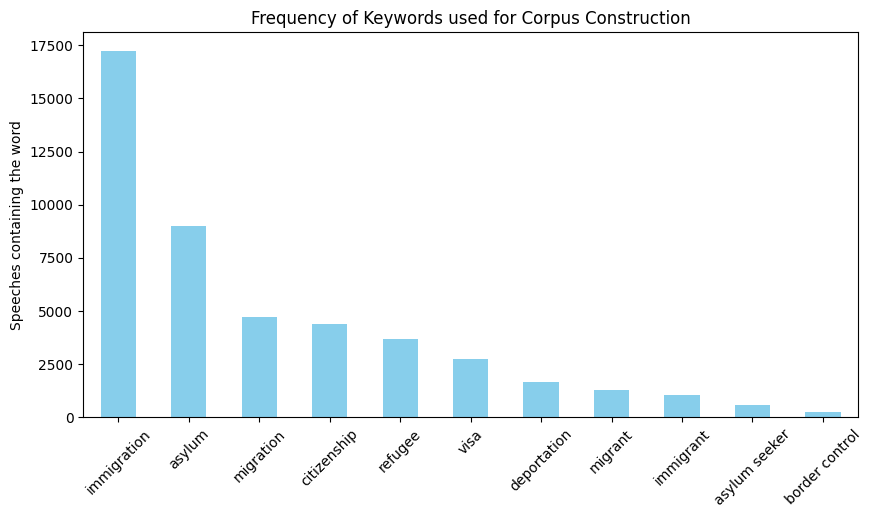

In [17]:
# Frequency of specific keywords within the filtered corpus
keyword_counts = {kw: df_migration['speech'].str.contains(rf'\b{kw}\b', case=False).sum() for kw in keywords}
kw_df = pd.Series(keyword_counts).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
kw_df.plot(kind='bar', color='skyblue')
plt.title('Frequency of Keywords used for Corpus Construction')
plt.ylabel('Speeches containing the word')
plt.xticks(rotation=45)
plt.show()

### Preprocessing

In [18]:
from tqdm import tqdm
tqdm.pandas()

# Load the model
nlp = spacy.load("en_core_web_sm")

# parliamentary noise + some other words
parliamentary_stops = {
    'hon', 'gentleman', 'member', 'right', 'honourable', 'house', 'commons',
    'mr', 'mrs', 'ms', 'dr', 'sir', 'madam', 'speaker', 'minister', 'secretary',
    'parliament', 'debate', 'amendment', 'clause', 'bill', 'lord',
    'noble', 'lady', 'friend', 'colleague', 'question', 'reply', 'statement',
    'today', 'now', 'perhaps', 'really', 'merely', 'simply', 'indeed',
    'one', 'two', 'must', 'shall', 'may', 'also', 'would', 'could', 'said',
    'year year'
}

# Combining with SpaCy's standard English stopwords
all_stops = nlp.Defaults.stop_words.union(parliamentary_stops)

def fast_preprocess_batch(texts):
    # Process as a stream (much faster than .apply)
    # Disable parser and ner to save processing time
    docs = nlp.pipe(texts, disable=['parser', 'ner'], batch_size=200)
    
    cleaned_speeches = []
    for doc in tqdm(docs, total=len(texts), desc="Cleaning Speeches"):        
        # Keep only Nouns and Adjectives
        tokens = [
            token.lemma_ for token in doc 
            if token.pos_ in ['NOUN', 'ADJ', 'VERB'] 
            and token.lemma_ not in all_stops 
            and len(token.text) > 2
        ]
        cleaned_speeches.append(" ".join(tokens))
    return cleaned_speeches

# Apply to migration dataframe
df_migration['cleaned_text'] = fast_preprocess_batch(df_migration['speech'].tolist())

# Reset index
df_migration = df_migration.reset_index(drop=True)

print("Preprocessing complete. Analysis-ready corpus created.")

Cleaning Speeches: 100%|██████████| 58729/58729 [43:51<00:00, 22.32it/s]  


Preprocessing complete. Analysis-ready corpus created.


In [ ]:
df_migration.head()

,id,speech,display_as,party,constituency,mnis_id,date,time,colnum,speech_class,...,minor_heading,oral_heading,year,hansard_membership_id,speakerid,person_id,speakername,url,word_count,cleaned_text
0,uk.org.publicwhip/debate/1979-05-15a.51.2,Measures will be introduced to amend the law o...,Unknown,NaN,NaN,NaN,1979-05-15,NaN,51,Procedural,...,NaN,NaN,1979,NaN,NaN,NaN,Unknown,NaN,19,measure introduce amend law nationality change...
1,uk.org.publicwhip/debate/1979-05-15a.87.1,It falls to me to be first to congratulate the...,David Steel,Liberal,"Roxburgh, Selkirk and Peebles",949.0,1979-05-15,16:17,87,Speech,...,NaN,NaN,1979,2357.0,uk.org.publicwhip/member/21008,NaN,Mr. David Steel,NaN,1575,fall congratulate political address office kno...
2,uk.org.publicwhip/debate/1979-05-15a.173.1,"The hon. Member for Sheffield, Heeley (Mr. Hoo...",Hal Miller,Conservative,Bromsgrove and Redditch,1187.0,1979-05-15,20:30,173,Speech,...,NaN,NaN,1979,9302.0,uk.org.publicwhip/member/29786,NaN,Mr. Miller,NaN,518,usual mistaken intervention temporary rescue p...
3,uk.org.publicwhip/debate/1979-05-16a.271.1,The House has listened with great pleasure and...,Anthony Kershaw,Conservative,Stroud,888.0,1979-05-16,17:22,271,Speech,...,NaN,NaN,1979,7224.0,uk.org.publicwhip/member/16882,NaN,Mr. Anthony Kershaw,NaN,2035,listen great pleasure satisfaction admire flue...
4,uk.org.publicwhip/debate/1979-05-16a.324.1,I wish at the outset to express sincere congra...,Frank McElhone,Labour,"Glasgow, Queen's Park",917.0,1979-05-16,19:58,324,Speech,...,NaN,NaN,1979,8478.0,uk.org.publicwhip/member/18173,NaN,Mr. Frank McElhone,NaN,3573,wish outset express sincere congratulation jun...


In [ ]:
# Baseline check
print("Original:", df_migration['speech'].iloc[0][:120])
print("Cleaned:", df_migration['cleaned_text'].iloc[0][:120])

Original: Measures will be introduced to amend the law on nationality and to make changes in the control of immigration.
Cleaned: measure introduce amend law nationality change control immigration


### Bag-of-words

In [ ]:
import pandas as pd

# Initialize
bow = CountVectorizer(max_df=0.95, min_df=2, max_features=1000)

# Create BoW matrix from cleaned texts
X_bow = bow.fit_transform(df_migration['cleaned_text'].tolist())

# Convert to readable DataFrame
bow_df = pd.DataFrame(
    X_bow.toarray(),
    columns=bow.get_feature_names_out(),
    index=[f"speech_{i}" for i in range(len(df_migration))]
)

# Display matrix
print(bow_df.head())
print(f"\nMatrix shape: {bow_df.shape}")

          ability  able  abuse  accept  access  accommodation  accord  \
speech_0        0     0      0       0       0              0       0   
speech_1        1     0      0       0       0              0       0   
speech_2        0     0      0       1       0              0       0   
speech_3        0     3      0       0       0              3       1   
speech_4        0     0      0       1       0              3       0   

          account  achieve  acknowledge  ...  work  worker  world  worry  \
speech_0        0        0            0  ...     0       0      0      0   
speech_1        0        0            0  ...     1       0      0      0   
speech_2        0        1            0  ...     0       0      0      0   
speech_3        0        0            0  ...     0       0      0      0   
speech_4        0        3            0  ...    13       0      3      4   

          worth  write  wrong  year  yesterday  young  
speech_0      0      0      0     0          0  

In [ ]:
X_bow

<58729x1000 sparse matrix of type '<class 'numpy.int64'>'
	with 4281434 stored elements in Compressed Sparse Row format>

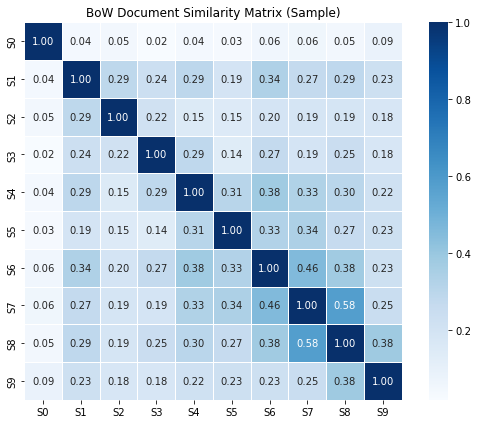

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Create BoW matrix
bow = CountVectorizer(max_features=1000)
X_bow = bow.fit_transform(df_migration['cleaned_text'])

# Sample first 10 documents for visibility
sample_size = min(10, len(df_migration)) # len(df_migration) = 58729
sample_bow = X_bow[:sample_size]

# Calculate cosine similarity
S_bow = cosine_similarity(sample_bow)

# Visualize
plt.figure(figsize=(8, 6))
sns.heatmap(
    S_bow, 
    annot=True, 
    cmap="Blues", 
    fmt=".2f",
    xticklabels=[f"S{i}" for i in range(sample_size)],
    yticklabels=[f"S{i}" for i in range(sample_size)],
    square=True,
    linewidths=0.5
)
plt.title("BoW Document Similarity Matrix (Sample)")
plt.tight_layout()
plt.show()

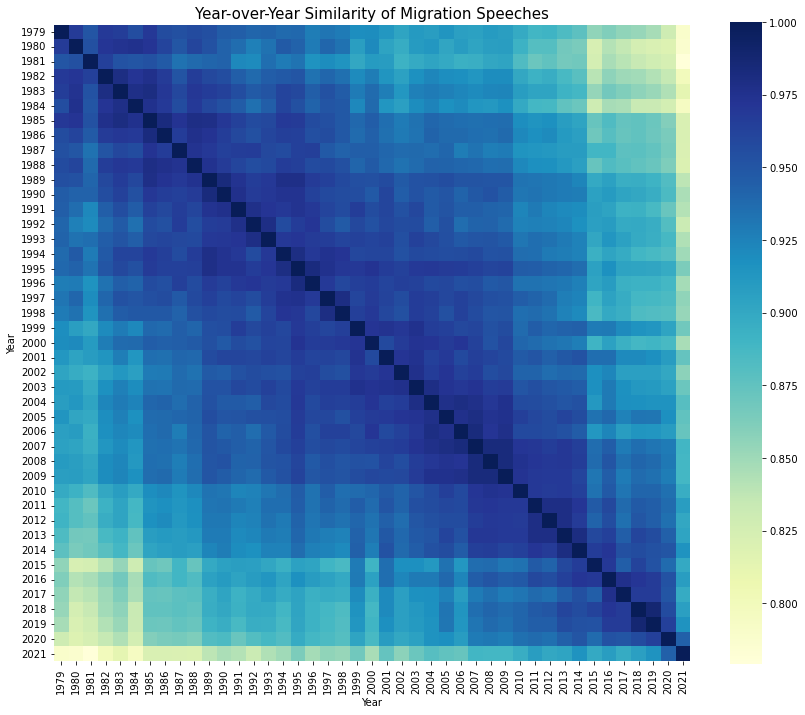

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Vectorize the entire dataset
# We use a larger max_features here to capture more nuance for the similarity math
bow = CountVectorizer(max_features=2000, stop_words='english')
X_bow = bow.fit_transform(df_migration['cleaned_text'])

# 2. Aggregate the sparse matrix by Year
# We create a DataFrame of the counts and group by 'year'
bow_df = pd.DataFrame(X_bow.toarray(), columns=bow.get_feature_names_out())
bow_df['year'] = df_migration['year'].values
yearly_vectors = bow_df.groupby('year').mean()

# 3. Calculate Cosine Similarity between the Years
# Instead of document-vs-document, this is year-vs-year
year_labels = yearly_vectors.index
S_yearly = cosine_similarity(yearly_vectors)

# 4. Visualize the Year-over-Year Similarity Matrix
plt.figure(figsize=(12, 10))
sns.heatmap(
    S_yearly, 
    annot=False, 
    cmap="YlGnBu", 
    xticklabels=year_labels,
    yticklabels=year_labels,
    square=True
)

plt.title("Year-over-Year Similarity of Migration Speeches", fontsize=15)
plt.xlabel("Year")
plt.ylabel("Year")
plt.tight_layout()
plt.show()

### Feature Extraction (TF-IDF)

Top TF-IDF Baseline Terms for the Migration Corpus:
             term        score
1272       people  2540.050623
417       country  1996.323586
885   immigration  1721.850984
1991         year  1605.562265
1980         work  1465.239250
1488      refugee  1420.505397
1161         need  1394.699395
139        asylum  1370.221941
1832         time  1312.037876
311          come  1286.453295


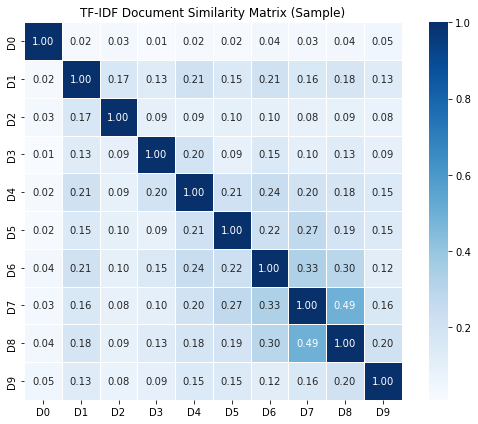

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns
import matplotlib.pyplot as plt

# Create TF-IDF with bigrams
tfidf = TfidfVectorizer(
    max_features=2000, 
    ngram_range=(1, 2)  # Words and bigrams
)
tfidf_matrix = tfidf.fit_transform(df_migration['cleaned_text'])

# Get top terms
feature_names = tfidf.get_feature_names_out()
densities = np.asarray(tfidf_matrix.sum(axis=0)).ravel()
tfidf_results = pd.DataFrame({
    'term': feature_names, 
    'score': densities
}).sort_values('score', ascending=False)

print("Top TF-IDF Baseline Terms for the Migration Corpus:")
print(tfidf_results.head(10))

# Document similarity heatmap (sample of first 10 documents)
sample_size = min(10, len(df_migration))
sample_matrix = tfidf_matrix[:sample_size]

# Calculate cosine similarity
S = cosine_similarity(sample_matrix)

# Visualize
plt.figure(figsize=(8, 6))
sns.heatmap(
    S, 
    annot=True, 
    cmap="Blues", 
    fmt=".2f",
    xticklabels=[f"D{i}" for i in range(sample_size)],
    yticklabels=[f"D{i}" for i in range(sample_size)],
    square=True,
    linewidths=0.5
)
plt.title("TF-IDF Document Similarity Matrix (Sample)")
plt.tight_layout()
plt.show()

In [19]:
pre_2015 = df_migration[df_migration['year'] < 2015]['cleaned_text']
post_2015 = df_migration[df_migration['year'] >= 2015]['cleaned_text']

def get_top_tfidf(corpus, n=10):
    vectorizer = TfidfVectorizer(max_features=1000)
    matrix = vectorizer.fit_transform(corpus)
    scores = zip(vectorizer.get_feature_names_out(), matrix.sum(axis=0).tolist()[0])
    return sorted(scores, key=lambda x: x[1], reverse=True)[:n]

pre_2015_tfid=get_top_tfidf(pre_2015)
post_2015_tfid=get_top_tfidf(post_2015)

In [ ]:
pd.DataFrame(pre_2015_tfid, columns=['word', 'NF score'])

,word,NF score
0,people,2208.554815
1,country,1751.385761
2,immigration,1468.908043
3,year,1467.297383
4,asylum,1290.077911
5,work,1204.342557
6,time,1200.597077
7,need,1158.406456
8,case,1136.991326
9,come,1099.374209


In [ ]:
pd.DataFrame(post_2015_tfid, columns=['word', 'NF score'])

,word,NF score
0,people,734.338717
1,country,557.163814
2,refugee,537.155462
3,immigration,522.926186
4,work,475.628810
5,need,445.462237
6,child,414.386661
7,support,406.234829
8,year,395.633358
9,come,391.097997


### Visualizing bigrams

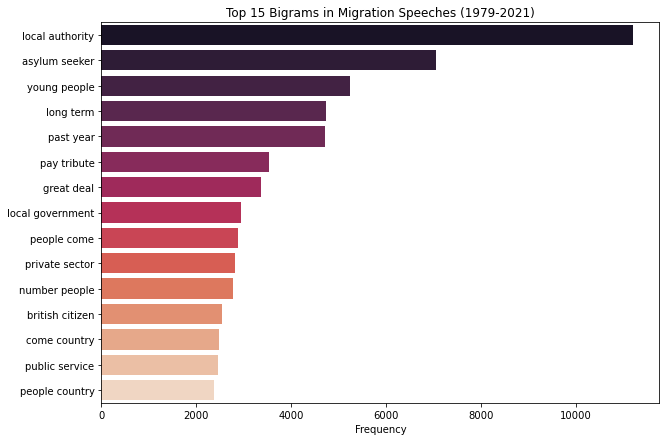

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

def get_top_ngram(corpus, n=None, g=2):
    # Filter out any empty rows that might have resulted from preprocessing
    corpus = [text for text in corpus if isinstance(text, str) and len(text) > 0]
    
    # Initialize CountVectorizer for n-grams
    vec = CountVectorizer(ngram_range=(g, g)).fit(corpus)
    bag_of_words = vec.transform(corpus)
    
    sum_words = bag_of_words.sum(axis=0) 
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key = lambda x: x[1], reverse=True)
    return words_freq[:n]

# Visualize Top Bigrams
top_bigrams = get_top_ngram(df_migration['cleaned_text'], n=15, g=2)
x, y = map(list, zip(*top_bigrams))

plt.figure(figsize=(10, 7))
sns.barplot(x=y, y=x, palette="rocket")
plt.title("Top 15 Bigrams in Migration Speeches (1979-2021)")
plt.xlabel("Frequency")
plt.show()

In [ ]:
top_bigrams

[('local authority', 11201),
 ('asylum seeker', 7053),
 ('young people', 5247),
 ('long term', 4737),
 ('past year', 4713),
 ('pay tribute', 3523),
 ('great deal', 3354),
 ('local government', 2940),
 ('people come', 2878),
 ('private sector', 2815),
 ('number people', 2778),
 ('british citizen', 2540),
 ('come country', 2486),
 ('public service', 2459),
 ('people country', 2375)]

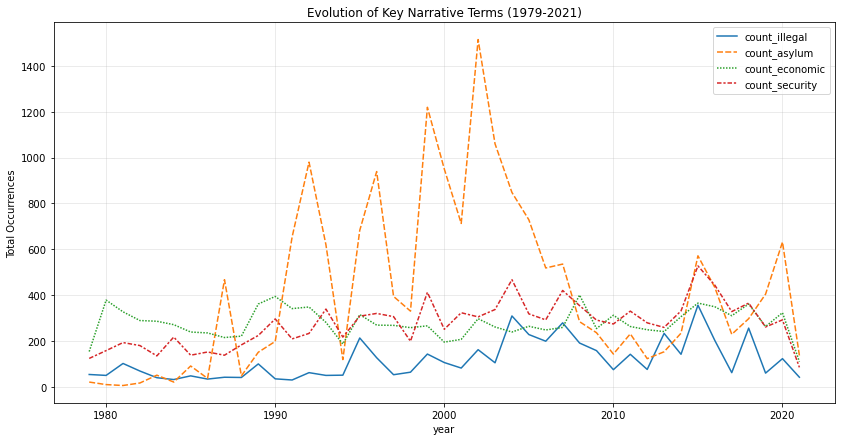

In [ ]:
# Create a pivot table for yearly word counts
# We pick words that relate to our hypotheses
target_words = ['illegal', 'asylum', 'economic', 'security']

# Simple function to count word occurrences per year
for word in target_words:
    df_migration[f'count_{word}'] = df_migration['cleaned_text'].str.count(word)

yearly_trends = df_migration.groupby('year')[[f'count_{word}' for word in target_words]].sum()

plt.figure(figsize=(14, 7))
sns.lineplot(data=yearly_trends)
plt.title("Evolution of Key Narrative Terms (1979-2021)")
plt.ylabel("Total Occurrences")
plt.grid(True, alpha=0.3)
plt.show()

In [23]:
# Final Selection of columns submission
# As required by the Project Work Description 
milestone_2_df = df_migration[['date', 'year', 'speakername', 'party', 'speech', 'cleaned_text']]

# milestone_2_df.to_csv('migration_narratives_final_corpus_verbs.csv', index=False)
milestone_2_df.to_csv('/Volumes/samsung_t7/migration_narratives_final_corpus_verbs.csv', index=False)

print("Milestone 2 Analysis-ready corpus exported.")

Milestone 2 Analysis-ready corpus exported.


### Statistical description of the final corpus

In [ ]:
print("Number of documents:", len(milestone_2_df))
print("Number of unique speakers:", milestone_2_df["speakername"].nunique())
print("Average document length (tokens):", round(milestone_2_df["cleaned_text"].str.split().str.len().mean(), 1))
print("Median document length (tokens):", milestone_2_df["cleaned_text"].str.split().str.len().median())
print("Total tokens:", milestone_2_df["cleaned_text"].str.split().str.len().sum())
print("Time span:", milestone_2_df["year"].min(), "–", milestone_2_df["year"].max())

Number of documents: 58729
Number of unique speakers: 4223
Average document length (tokens): 165.8
Median document length (tokens): 70.0
Total tokens: 9734375
Time span: 1979 – 2021


### LDA

In [ ]:
# df = pd.read_csv("migration_narratives_final_corpus (1).csv")
df = pd.read_csv("/Volumes/samsung_t7/migration_narratives_final_corpus_verbs.csv")
df

,date,year,speakername,party,speech,cleaned_text
0,1979-05-15,1979,Unknown,NaN,Measures will be introduced to amend the law o...,measure introduce amend law nationality change...
1,1979-05-15,1979,Mr. David Steel,Liberal,It falls to me to be first to congratulate the...,fall congratulate political address office kno...
2,1979-05-15,1979,Mr. Miller,Conservative,"The hon. Member for Sheffield, Heeley (Mr. Hoo...",usual mistaken intervention temporary rescue p...
3,1979-05-16,1979,Mr. Anthony Kershaw,Conservative,The House has listened with great pleasure and...,listen great pleasure satisfaction admire flue...
4,1979-05-16,1979,Mr. Frank McElhone,Labour,I wish at the outset to express sincere congra...,wish outset express sincere congratulation jun...
...,...,...,...,...,...,...
58724,2021-04-28,2021,John McDonnell,Labour,I find it hard to believe that we are having t...,find hard believe delegate legislation introdu...
58725,2021-04-28,2021,Jim Shannon,Democratic Unionist Party,I thank the Minister and all the contributors ...,thank contributor issue great importance recog...
58726,2021-04-28,2021,Chris Philp,Conservative,I thank all the Members who have contributed t...,thank contribute discussion thank consider tho...
58727,2021-04-29,2021,Mike Kane,Labour,"My hon. Friend the Member for Ealing, Southall...",bang money operate onerous manual assurance ch...


In [25]:
!pip install gensim

/Users/mac/miniforge3/envs/text_mining/lib/python3.12/pty.py:95: DeprecationWarning: This process (pid=87623) is multi-threaded, use of forkpty() may lead to deadlocks in the child.
  pid, fd = os.forkpty()


In [26]:
import gensim
from gensim.corpora import Dictionary

# If cleaned_text contains strings:
texts = df["cleaned_text"].apply(lambda x: x.split() if isinstance(x, str) else []).tolist()

# Build dictionary
dictionary = Dictionary(texts)

# Remove rare and frequent words
dictionary.filter_extremes(no_below=20, no_above=0.5)

# Bag-of-Words representation
corpus = [dictionary.doc2bow(t) for t in texts]

print(len(dictionary), len(corpus))

10281 58729


In [27]:
from gensim.models import LdaModel
import pickle

lda = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=13, # number of latent topics we want to find (ad-hoc choice; we later do a grid search)
    passes=10, # how many times LDA sweeps the whole corpus while updating its parameters (more passes = better fit but slower)
    random_state=42
)

# We also save the model, the dictionary and the BoW corpus so we can reload them without retraining
lda.save("lda_model_k13.gensim")
dictionary.save("lda_dictionary_k13.dict")
with open("lda_corpus_k13.pkl", "wb") as f:
    pickle.dump(corpus, f, protocol=pickle.HIGHEST_PROTOCOL)

In [28]:

for k in range(13):
    print(f"Topic {k}: {lda.print_topic(k, topn=10)}")

Topic 0: 0.048*"local" + 0.023*"authority" + 0.020*"area" + 0.019*"council" + 0.017*"housing" + 0.014*"community" + 0.012*"constituency" + 0.010*"need" + 0.010*"new" + 0.010*"home"
Topic 1: 0.010*"issue" + 0.010*"deal" + 0.009*"point" + 0.008*"matter" + 0.008*"power" + 0.007*"time" + 0.007*"law" + 0.007*"case" + 0.007*"way" + 0.007*"think"
Topic 2: 0.037*"police" + 0.024*"crime" + 0.022*"criminal" + 0.016*"offence" + 0.013*"law" + 0.012*"prison" + 0.012*"court" + 0.011*"justice" + 0.011*"officer" + 0.010*"victim"
Topic 3: 0.054*"child" + 0.022*"woman" + 0.019*"support" + 0.018*"school" + 0.017*"need" + 0.016*"work" + 0.016*"family" + 0.015*"people" + 0.015*"abuse" + 0.014*"victim"
Topic 4: 0.022*"year" + 0.020*"pay" + 0.018*"tax" + 0.016*"cost" + 0.015*"people" + 0.015*"scheme" + 0.014*"benefit" + 0.012*"increase" + 0.012*"money" + 0.010*"rate"
Topic 5: 0.032*"people" + 0.012*"want" + 0.012*"know" + 0.011*"come" + 0.011*"year" + 0.010*"think" + 0.010*"time" + 0.009*"country" + 0.008*"p

In [29]:
for k in range(lda.num_topics):
    terms = lda.get_topic_terms(k, topn=15)
    # Converts a numeric word ID back into a string
    # We write '_' instead of a variable name because: we don’t need the probability
    words = [dictionary[word_id] for word_id, _ in terms]
    print(f"Topic {k}: {', '.join(words)}")

Topic 0: local, authority, area, council, housing, community, constituency, need, new, home, city, people, year, town, build
Topic 1: issue, deal, point, matter, power, time, law, case, way, think, legislation, agreement, change, clear, decision
Topic 2: police, crime, criminal, offence, law, prison, court, justice, officer, victim, offender, use, case, traffic, public
Topic 3: child, woman, support, school, need, work, family, people, abuse, victim, young, care, domestic, education, help
Topic 4: year, pay, tax, cost, people, scheme, benefit, increase, money, rate, credit, income, cut, fund, support
Topic 5: people, want, know, come, year, think, time, country, party, thing, vote, hear, good, speak, tell
Topic 6: citizen, section, british, citizenship, leave, person, provision, line, apply, subsection, regulation, national, new, page, end
Topic 7: immigration, people, country, asylum, system, case, come, visa, number, migrant, family, claim, seeker, detention, year
Topic 8: health, se

In [30]:
topics = []

for k in range(lda.num_topics):
    # list of (word_id, probability)
    terms = lda.get_topic_terms(k, topn=15)

    # convert word_ids to actual words
    words = [dictionary[word_id] for word_id, _ in terms]

    topics.append({
        "topic_id": k,
        "top_words": words
    })

import json
with open("lda_topics_k13.json", "w") as f:
    json.dump(topics, f, indent=2)

In [31]:
import numpy as np
import pandas as pd

def doc_topic_matrix(model, corpus, num_topics):
    # initialize a (documents x topics) matrix of zeros
    mat = np.zeros((len(corpus), num_topics))
    # loop through the corpus: i = doc index, bow = BoW for that doc
    for i, bow in enumerate(corpus):
        # ask the model which topics are present in this document
        # and write their probabilities into the matrix
        for tid, prob in model.get_document_topics(bow):
            mat[i, tid] = prob
    return mat

theta = doc_topic_matrix(lda, corpus, lda.num_topics)

# Turn theta into a DataFrame with readable column names (topic_0, ..., topic_12)
theta_df = pd.DataFrame(
    theta,
    columns=[f"topic_{k}" for k in range(lda.num_topics)]
)

# Save to CSV
theta_df.to_csv("lda_doc_topic_k13.csv", index=False)

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58729 entries, 0 to 58728
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   date          58729 non-null  object
 1   year          58729 non-null  int64 
 2   speakername   58729 non-null  object
 3   party         57967 non-null  object
 4   speech        58729 non-null  object
 5   cleaned_text  58727 non-null  object
dtypes: int64(1), object(5)
memory usage: 2.7+ MB


In [33]:
df_with_theta = pd.concat(
    [df[['speech']].reset_index(drop=True), theta_df.reset_index(drop=True)],
    axis=1
)

# Save for later and display
df_with_theta.to_csv("top_docs_for_topics13.csv", index=False)
df_with_theta

,speech,topic_0,topic_1,topic_2,topic_3,topic_4,topic_5,topic_6,topic_7,topic_8,topic_9,topic_10,topic_11,topic_12
0,Measures will be introduced to amend the law o...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.416735,0.489242,0.000000,0.000000,0.000000,0.000000,0.000000
1,It falls to me to be first to congratulate the...,0.044112,0.256943,0.000000,0.027479,0.040170,0.430943,0.000000,0.000000,0.000000,0.042201,0.000000,0.072448,0.084911
2,"The hon. Member for Sheffield, Heeley (Mr. Hoo...",0.019789,0.457947,0.000000,0.000000,0.251044,0.000000,0.000000,0.000000,0.000000,0.000000,0.025070,0.115168,0.119012
3,The House has listened with great pleasure and...,0.065187,0.157347,0.000000,0.122544,0.054350,0.188557,0.039656,0.124213,0.000000,0.000000,0.000000,0.025129,0.213621
4,I wish at the outset to express sincere congra...,0.127475,0.042953,0.011301,0.404776,0.048338,0.241634,0.000000,0.000000,0.073373,0.000000,0.000000,0.017351,0.032518
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58724,I find it hard to believe that we are having t...,0.000000,0.116907,0.173183,0.187793,0.000000,0.179807,0.000000,0.238303,0.000000,0.080592,0.000000,0.000000,0.000000
58725,I thank the Minister and all the contributors ...,0.012614,0.000000,0.000000,0.152616,0.000000,0.125557,0.000000,0.361958,0.000000,0.070738,0.272674,0.000000,0.000000
58726,I thank all the Members who have contributed t...,0.000000,0.168110,0.000000,0.215186,0.000000,0.000000,0.000000,0.417791,0.000000,0.000000,0.193896,0.000000,0.000000
58727,"My hon. Friend the Member for Ealing, Southall...",0.000000,0.000000,0.399073,0.000000,0.088645,0.144338,0.000000,0.078042,0.000000,0.268645,0.000000,0.000000,0.000000


In [34]:

topic_cols = [c for c in df_with_theta.columns if c.startswith("topic_")]

def show_top_docs_by_topic(df, topic_cols, top_n=10):
    for t in topic_cols:
        print("\n" + "="*80)
        print(f"{t}: top {top_n} texts")
        print("="*80)

        # Sort by this topic's probability, descending; keep top_n
        top = (
            df.loc[df[t].notna(), ["speech", t]]
              .sort_values(t, ascending=False)
              .head(top_n)
        )

        for i, row in top.iterrows():
            prob = row[t]
            text  = str(row["speech"])

            # Shorten long speeches for readable printing
            text_short = (text[:500] + "…") if len(text) > 500 else text

            print(f"\n[{t} = {prob:.3f}] \n{text_short}\n")

show_top_docs_by_topic(df_with_theta, topic_cols, top_n=10)


topic_0: top 10 texts

[topic_0 = 0.972] 
I hope that the Minister will recognise that the problem is not with the overall methodology but with the application of the methodology to specific areas, especially rural counties such as Gloucestershire — which the hon. Member for Stroud (Mr. Drew) mentioned — and my local county of Somerset. We cannot sustain the projected migration levels without employment. We cannot sustain the use of brown-field sites when they do not exist in our rural counties, but building on green-field sites would c…


[topic_0 = 0.968] 
The Government's commitment to providing more affordable housing is very welcome, but one of the great needs in my constituency is more rented housing, as well as more affordable housing to buy. What do the Government plan to do to increase the availability of rented housing for those who either cannot afford or do not wish to buy, and what role do they envisage local councils having in providing that rented housing?


[topic_0 = 

In [35]:

!pip install pyLDAvis

/Users/mac/miniforge3/envs/text_mining/lib/python3.12/pty.py:95: DeprecationWarning: This process (pid=87623) is multi-threaded, use of forkpty() may lead to deadlocks in the child.
  pid, fd = os.forkpty()


In [36]:
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis

# Builds the interactive visualization
vis = gensimvis.prepare(lda, corpus, dictionary, sort_topics=False)
# Save to a standalone HTML file
pyLDAvis.save_html(vis, "lda_pyldavis_k13.html")

In [37]:
pyLDAvis.display(vis)

In [38]:
# TOPIC PREVALENCE OVER TIME: for each year, what share of speeches has topic k as their
# single dominant topic? Plotting this over years shows how the political conversation shifts.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# --- 1) Build theta (doc-topic matrix) ---
K = lda.num_topics

def doc_topic_dist(model, bow, K):
    """Full (length-K) topic distribution for a single document."""
    # minimum_probability=0 forces gensim to return ALL topics
    # (by default tiny probabilities are dropped).
    dist = model.get_document_topics(bow, minimum_probability=0)
    out = np.zeros(K)
    for tid, p in dist:
        out[tid] = p
    return out

# Stack all per-doc distributions into a (N_docs x K) matrix
theta = np.vstack([doc_topic_dist(lda, bow, K) for bow in corpus])
# The single most-likely topic for each document
dominant_topic = theta.argmax(axis=1)

# --- 2) Add dominant topic to dataframe ---
df_viz = df.copy()
df_viz["dominant_topic"] = dominant_topic

# --- 3) Compute share_by_year (share of docs where topic is dominant) ---
# For each year, count docs per dominant topic, then normalize by the
# total number of docs in that year -> shares sum to 1 per year.
share_by_year = (
    df_viz.groupby(["year", "dominant_topic"])
          .size()
          .groupby(level=0)
          .apply(lambda s: s / s.sum())
          .unstack(fill_value=0)
          .sort_index()
)

# --- 4) Make it plot-safe (handles tuples / strings / MultiIndex issues) ---
if isinstance(share_by_year.index, pd.MultiIndex):
    share_by_year.index = share_by_year.index.get_level_values(0)

share_by_year.index = pd.to_numeric(share_by_year.index, errors="coerce")
share_by_year = share_by_year[share_by_year.index.notna()]
share_by_year.index = share_by_year.index.astype(int)

share_by_year.columns = [
    c[0] if isinstance(c, tuple) and len(c) == 1 else c
    for c in share_by_year.columns
]

share_by_year = share_by_year.apply(pd.to_numeric, errors="coerce").fillna(0.0)
share_by_year = share_by_year.sort_index()


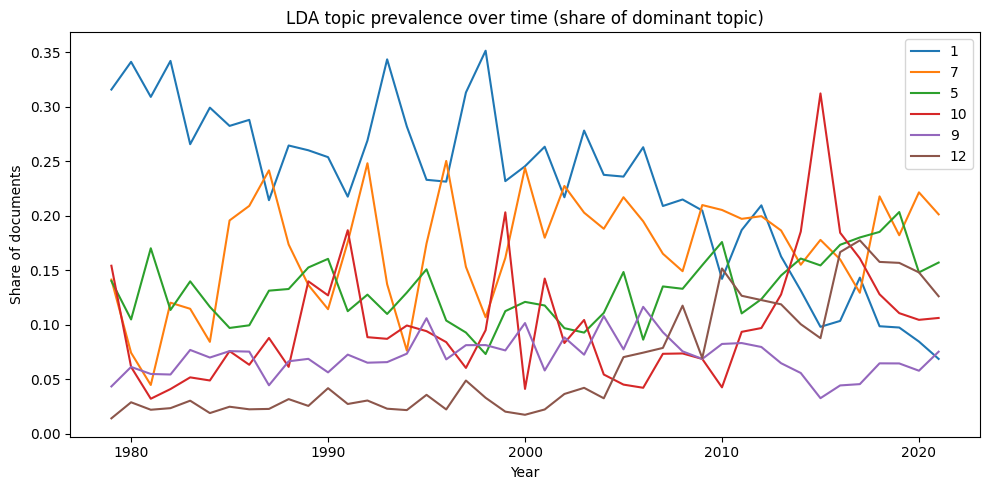

In [39]:
top_topics = (
    share_by_year.mean(axis=0) # mean share across years per topic
    .sort_values(ascending=False) # largest first
    .head(6) # keep the top 6
    .index
    .tolist()
)
plt.figure(figsize=(10, 5))
for t in top_topics:
    # Use our human-readable label if it exists, otherwise "Topic k"
    #label = topic_labels.get(t, f"Topic {t}")
    label = t
    plt.plot(
        share_by_year.index.values,
        share_by_year[t].values,
        label=label
    )

plt.title("LDA topic prevalence over time (share of dominant topic)")
plt.xlabel("Year")
plt.ylabel("Share of documents")
plt.legend()
plt.tight_layout()
plt.show()


### LDA 1997

In [40]:


# If cleaned_text contains strings:
df_1979 = df.loc[df["year"] == 1979, :]
print(df_1979.head())
texts_1979 = df_1979["cleaned_text"].apply(lambda x: x.split() if isinstance(x, str) else []).tolist()

# Build dictionary
dictionary = Dictionary(texts_1979)

# Remove rare and frequent words
dictionary.filter_extremes(no_below=20, no_above=0.5)

# Bag-of-Words representation
corpus = [dictionary.doc2bow(t) for t in texts_1979]

print(len(dictionary), len(corpus))

         date  year          speakername         party  \
0  1979-05-15  1979              Unknown           NaN   
1  1979-05-15  1979      Mr. David Steel       Liberal   
2  1979-05-15  1979           Mr. Miller  Conservative   
3  1979-05-16  1979  Mr. Anthony Kershaw  Conservative   
4  1979-05-16  1979   Mr. Frank McElhone        Labour   

                                              speech  \
0  Measures will be introduced to amend the law o...   
1  It falls to me to be first to congratulate the...   
2  The hon. Member for Sheffield, Heeley (Mr. Hoo...   
3  The House has listened with great pleasure and...   
4  I wish at the outset to express sincere congra...   

                                        cleaned_text  
0  measure introduce amend law nationality change...  
1  fall congratulate political address office kno...  
2  usual mistaken intervention temporary rescue p...  
3  listen great pleasure satisfaction admire flue...  
4  wish outset express sincere congratu

In [42]:

lda_1979 = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=13, # number of latent topics we want to find (ad-hoc choice; we later do a grid search)
    passes=10, # how many times LDA sweeps the whole corpus while updating its parameters (more passes = better fit but slower)
    random_state=42
)

# We also save the model, the dictionary and the BoW corpus so we can reload them without retraining
lda_1979.save("lda_model_k13_1979.gensim")
dictionary.save("lda_dictionary_k13_1979.dict")
with open("lda_corpus_k13_1979.pkl", "wb") as f:
    pickle.dump(corpus, f, protocol=pickle.HIGHEST_PROTOCOL)

In [43]:
for k in range(lda_1979.num_topics):
    terms = lda_1979.get_topic_terms(k, topn=15)
    # Converts a numeric word ID back into a string
    # We write '_' instead of a variable name because: we don’t need the probability
    words = [dictionary[word_id] for word_id, _ in terms]
    print(f"Topic {k}: {', '.join(words)}")

Topic 0: service, people, organisation, provide, voluntary, work, need, local, constituency, tax, import, country, increase, way, group
Topic 1: company, oil, union, trade, industry, board, day, time, use, believe, proposal, way, management, year, job
Topic 2: area, industry, policy, people, development, private, unemployment, sector, work, public, benefit, employment, industrial, job, way
Topic 3: refugee, country, problem, people, vietnamese, student, number, accept, world, international, year, help, agree, know, conference
Topic 4: year, industry, time, interest, public, problem, new, great, country, work, cent, world, land, come, point
Topic 5: hospital, authority, year, health, area, service, resource, increase, patient, pay, need, benefit, cent, new, know
Topic 6: citizen, people, country, come, rule, immigration, bear, year, number, woman, marriage, citizenship, change, area, proposal
Topic 7: matter, power, hope, think, provision, envisage, agreement, deal, time, way, view, pro

In [44]:
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis
# Builds the interactive visualization
vis_1979 = gensimvis.prepare(lda_1979, corpus, dictionary, sort_topics=False)
# Save to a standalone HTML file
pyLDAvis.save_html(vis_1979, "lda_pyldavis_k13_1979.html")

In [ ]:
pyLDAvis.display(vis_1979)

### LDA 2021

In [45]:


# If cleaned_text contains strings:
df_2021 = df.loc[df["year"] == 2021, :]
texts_2021 = df_2021["cleaned_text"].apply(lambda x: x.split() if isinstance(x, str) else []).tolist()

# Build dictionary
dictionary = Dictionary(texts_2021)

# Remove rare and frequent words
dictionary.filter_extremes(no_below=20, no_above=0.5)

# Bag-of-Words representation
corpus = [dictionary.doc2bow(t) for t in texts_2021]

print(len(dictionary), len(corpus))

lda_2021 = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=13, # number of latent topics we want to find (ad-hoc choice; we later do a grid search)
    passes=10, # how many times LDA sweeps the whole corpus while updating its parameters (more passes = better fit but slower)
    random_state=42
)

# We also save the model, the dictionary and the BoW corpus so we can reload them without retraining
lda_2021.save("lda_model_k13_2021.gensim")
dictionary.save("lda_dictionary_k13_2021.dict")
with open("lda_corpus_k13_2021.pkl", "wb") as f:
    pickle.dump(corpus, f, protocol=pickle.HIGHEST_PROTOCOL)
    
for k in range(lda_2021.num_topics):
    terms = lda_2021.get_topic_terms(k, topn=15)
    # Converts a numeric word ID back into a string
    # We write '_' instead of a variable name because: we don’t need the probability
    words = [dictionary[word_id] for word_id, _ in terms]
    print(f"Topic {k}: {', '.join(words)}")

# Builds the interactive visualization
vis_2021 = gensimvis.prepare(lda_2021, corpus, dictionary, sort_topics=False)
# Save to a standalone HTML file
pyLDAvis.save_html(vis_2021, "lda_pyldavis_k13.html")

572 452
Topic 0: world, year, global, child, aid, support, education, country, need, girl, time, policy, woman, international, climate
Topic 1: support, need, year, follow, welcome, public, power, time, lockdown, action, risk, concern, health, come, covid
Topic 2: asylum, accommodation, seeker, country, ensure, use, local, work, time, vaccine, system, pandemic, come, health, service
Topic 3: leave, issue, need, year, work, week, scheme, table, deal, family, support, address, able, month, constituent
Topic 4: business, support, industry, fund, work, help, scheme, year, community, new, provide, welcome, sector, pandemic, need
Topic 5: sanction, export, scottish, group, work, policy, security, regime, market, organisation, immigration, trade, space, impact, nation
Topic 6: genocide, law, human, international, foreign, report, national, issue, clear, include, action, legislation, country, concern, court
Topic 7: victim, abuse, domestic, support, need, woman, work, place, immigration, case,

In [46]:
pyLDAvis.display(vis_2021)

### BERT modelling

In [11]:
df = pd.read_csv("/Volumes/samsung_t7/migration_narratives_final_corpus_verbs.csv")

In [3]:
from sentence_transformers import SentenceTransformer

# Extract texts from the dataframe
speech_text = df['cleaned_text'].fillna("").astype(str).tolist()

# Create an embedding using the specified model
embedding_model = SentenceTransformer('thenlper/gte-small')

In [4]:
embeddings = embedding_model.encode(speech_text, show_progress_bar=True)

Batches: 100%|██████████| 1836/1836 [35:10<00:00,  1.15s/it] 


In [5]:
from umap import UMAP

# Reduce the input embeddings from 384 dimensions to 5 dimensions
umap_model = UMAP(
    n_components=5, 
    min_dist=0.0, 
    metric='cosine', 
    random_state=42
)

In [7]:
reduced_embeddings = umap_model.fit_transform(embeddings)

/Users/mac/miniforge3/envs/text_mining/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


In [6]:
umap_model

,n_neighbors,15
,n_components,5
,metric,'cosine'
,metric_kwds,None
,output_metric,'euclidean'
,output_metric_kwds,None
,n_epochs,None
,learning_rate,1.0
,init,'spectral'
,min_dist,0.0
,spread,1.0


In [8]:
from hdbscan import HDBSCAN

# We fit the model and extract the clusters
hdbscan_model = HDBSCAN(
    min_cluster_size=50, # larger = more stable generally
    metric='euclidean', # default in HBDSCAN
    cluster_selection_method='eom' # how HBDSCAN chooses the final clusters (Excess of Mass = balancing parent vs child stability across the tree)
).fit(reduced_embeddings)
clusters = hdbscan_model.labels_

# How many clusters did we generate?
len(set(clusters))

98

In [12]:
import pandas as pd

# Reduce 384-dimensional embeddings to 2 dimensions for easier visualization
reduced_embeddings = UMAP(
    n_components=2, # we only change this with respect to Step 2
    min_dist=0.0,
    metric='cosine',
    random_state=42
).fit_transform(embeddings)

/Users/mac/miniforge3/envs/text_mining/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


KeyboardInterrupt: 

In [14]:
from bertopic import BERTopic

# Train the model using the previously defined components
topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    verbose=True
).fit(speech_text, embeddings)

/Users/mac/miniforge3/envs/text_mining/lib/python3.12/site-packages/colorspacious/comparison.py:11: SyntaxWarning: invalid escape sequence '\D'
  """Computes the :math:`\Delta E` distance between pairs of colors.
2026-05-09 17:24:58,117 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-05-09 17:26:10,626 - BERTopic - Dimensionality - Completed ✓
2026-05-09 17:26:10,642 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-09 17:26:17,145 - BERTopic - Cluster - Completed ✓
2026-05-09 17:26:17,165 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-09 17:26:21,747 - BERTopic - Representation - Completed ✓


In [15]:
# Retrieve topic IDs, topic sizes, and keyword-based representations
topic_info = topic_model.get_topic_info()
display(topic_info)

,Topic,Count,Name,Representation,Representative_Docs
0,-1,30974,-1_people_country_work_year,"[people, country, work, year, need, time, come...",[week set plan transform rebalance criminal ju...
1,0,3267,0_asylum_seeker_claim_appeal,"[asylum, seeker, claim, appeal, application, c...","[year asylum seeker, pleased able secure treat..."
2,1,1505,1_rule_marriage_immigration_entry,"[rule, marriage, immigration, entry, husband, ...",[way want progress qualify regulation area imp...
3,2,1188,2_defence_force_nuclear_armed,"[defence, force, nuclear, armed, weapon, capab...",[recognise unsurpassed capability record profe...
4,3,1028,3_citizenship_british_citizen_territory,"[citizenship, british, citizen, territory, nat...",[welcome agree introduce year think fair long ...
...,...,...,...,...,...
93,92,57,92_genocide_humanitarian_rwandan_refugee,"[genocide, humanitarian, rwandan, refugee, int...",[grateful opportunity contribute important dou...
94,93,56,93_gay_homosexual_gender_homosexuality,"[gay, homosexual, gender, homosexuality, sex, ...",[prefer way matter point interest way fall sho...
95,94,55,94_immigration_immigrant_migration_country,"[immigration, immigrant, migration, country, n...",[grateful opportunity speak different tone con...
96,95,52,95_petition_petitioner_request_declare,"[petition, petitioner, request, declare, resid...",[think need manual handling course risk assess...


In [16]:
# Get the top 10 keywords and their c-TF-IDF weights for Topic 0
topic_model.get_topic(0)

[('asylum', np.float64(0.0634216785836467)),
 ('seeker', np.float64(0.04022797995705909)),
 ('claim', np.float64(0.018157497479147466)),
 ('appeal', np.float64(0.017903234073516978)),
 ('application', np.float64(0.0166740386958897)),
 ('country', np.float64(0.014482804746156956)),
 ('refugee', np.float64(0.013328416081431805)),
 ('applicant', np.float64(0.012667688015708082)),
 ('accommodation', np.float64(0.012122419676061322)),
 ('system', np.float64(0.011972473724665726))]

In [19]:
fig_heatmap = topic_model.visualize_heatmap(n_clusters=30)
fig_heatmap.write_html('heatmap_bert.html')

In [20]:
fig_hierarchical = topic_model.visualize_hierarchy()
fig_hierarchical.write_html('fig_hierarchical.html')

In [23]:
# Visualize topics and documents
fig = topic_model.visualize_documents(
    speech_text,
    reduced_embeddings=reduced_embeddings,
    width=1200,
    hide_annotations=True
)

# Update fonts of legend for easier visualization
fig.update_layout(font=dict(size=16))
fig.write_html('visualise_documents.html')

In [27]:
import matplotlib.pyplot as plt

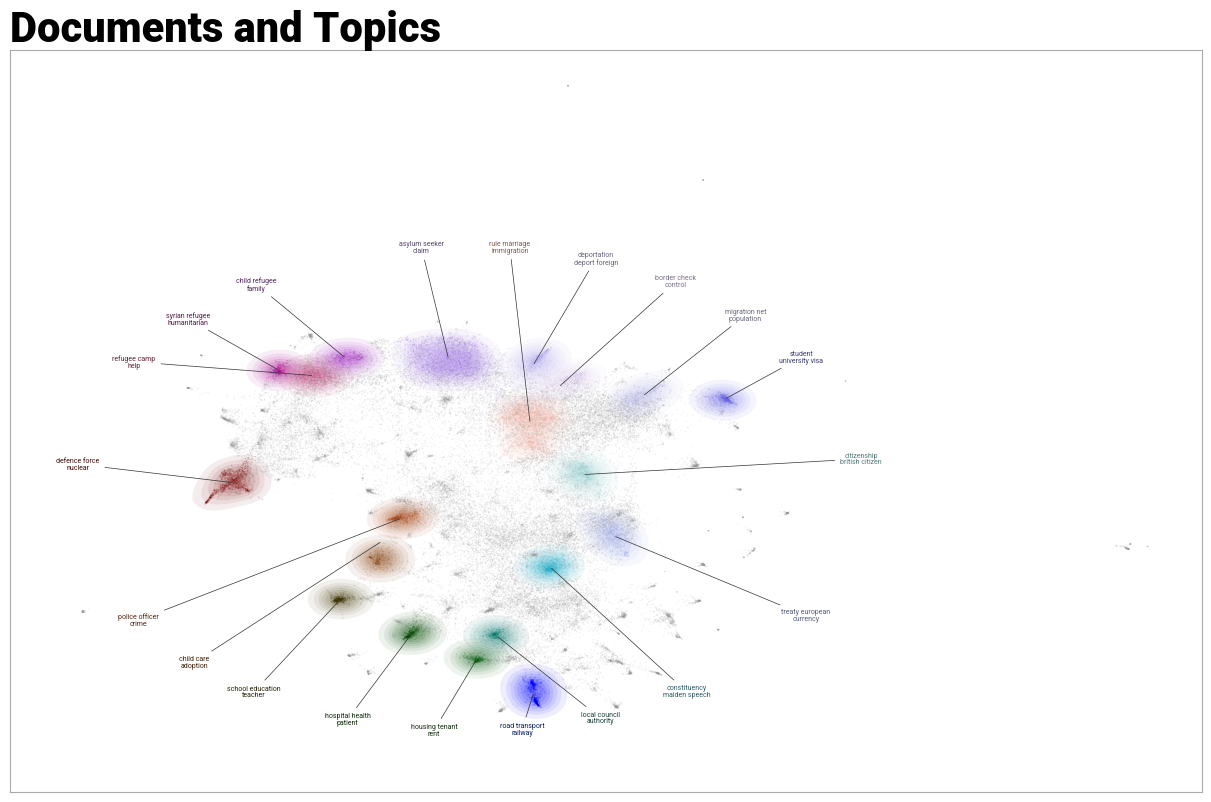

In [28]:
# Visualize topics and documents
fig = topic_model.visualize_document_datamap(
    speech_text,
    topics=list(range(20)), # showing only the first 20 topics
    reduced_embeddings=reduced_embeddings,
    width=1200,
    # label_font_size=11,
    # label_wrap_width=20,
    # use_medoids=True
)
plt.savefig("datamapplot.png", dpi=300)